**RNN for Semantic Analysis**

In [ ]:
# Import necessary libraries
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Sample training data: simple sentences and corresponding labels (1 = positive, 0 = negative)
sentences = [
    "I love this product",
    "This is an amazing movie",
    "I am so happy with the service",
    "This is the worst experience",
    "I hate this",
    "I am not satisfied",
]

# Labels for the sample sentences
labels = np.array([1, 1, 1, 0, 0, 0])  # Positive: 1, Negative: 0

# Step 1: Tokenize the text
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(sentences)
sequences = tokenizer.texts_to_sequences(sentences)

# Step 2: Padding the sequences to have the same length
maxlen = 5  # Maximum length of a sentence
X = pad_sequences(sequences, maxlen=maxlen)

# Step 3: Building the RNN model
model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=32, input_length=maxlen))
model.add(SimpleRNN(32, return_sequences=False))
model.add(Dense(1, activation='sigmoid'))

# Step 4: Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 5: Train the model
model.fit(X, labels, epochs=10, batch_size=2)

# Step 6: Testing the model on a new sentence
test_sentence = ["This is a fantastic experience"]
test_seq = tokenizer.texts_to_sequences(test_sentence)
test_padded = pad_sequences(test_seq, maxlen=maxlen)
prediction = model.predict(test_padded)

print("Sentiment (0 = Negative, 1 = Positive):", prediction[0][0])


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.1667 - loss: 0.7320  
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3333 - loss: 0.7028
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5000 - loss: 0.6802
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8333 - loss: 0.6564
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8333 - loss: 0.6332
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8333 - loss: 0.6101
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8333 - loss: 0.5861
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.5573
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.5308
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.4998
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
Sentiment (0 = Negative, 1 = Positive): 0.3663995


**Comparision of LSTM, GRU & RNN**

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

In [2]:
vocab_size = 10000

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=vocab_size)

print("Train size:", len(x_train))
print("Test size:", len(x_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train size: 25000
Test size: 25000


In [3]:
max_length = 200

x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

In [4]:
rnn_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [5]:
lstm_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [6]:
gru_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    GRU(64),
    Dense(1, activation='sigmoid')
])

gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [7]:
print("\nTraining RNN...")
history_rnn = rnn_model.fit(
    x_train, y_train,
    epochs=3,
    batch_size=64,
    validation_data=(x_test, y_test)
)


Training RNN...
Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 44s 106ms/step - accuracy: 0.7138 - loss: 0.5482 - val_accuracy: 0.8248 - val_loss: 0.4097
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 98ms/step - accuracy: 0.8597 - loss: 0.3349 - val_accuracy: 0.8163 - val_loss: 0.4281
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 99ms/step - accuracy: 0.9422 - loss: 0.1617 - val_accuracy: 0.8152 - val_loss: 0.4774


In [8]:
print("\nTraining LSTM...")
history_lstm = lstm_model.fit(
    x_train, y_train,
    epochs=3,
    batch_size=64,
    validation_data=(x_test, y_test)
)


Training LSTM...
Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 112s 279ms/step - accuracy: 0.7933 - loss: 0.4359 - val_accuracy: 0.8664 - val_loss: 0.3204
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 111s 284ms/step - accuracy: 0.9036 - loss: 0.2471 - val_accuracy: 0.8650 - val_loss: 0.3296
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 142s 284ms/step - accuracy: 0.9334 - loss: 0.1749 - val_accuracy: 0.8716 - val_loss: 0.3547


In [9]:
print("\nTraining GRU...")
history_gru = gru_model.fit(
    x_train, y_train,
    epochs=3,
    batch_size=64,
    validation_data=(x_test, y_test)
)


Training GRU...
Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 137s 344ms/step - accuracy: 0.7950 - loss: 0.4283 - val_accuracy: 0.8618 - val_loss: 0.3298
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 135s 346ms/step - accuracy: 0.9021 - loss: 0.2473 - val_accuracy: 0.8598 - val_loss: 0.3374
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 126s 304ms/step - accuracy: 0.9372 - loss: 0.1684 - val_accuracy: 0.8696 - val_loss: 0.3492


In [10]:
rnn_acc = rnn_model.evaluate(x_test, y_test)[1]
lstm_acc = lstm_model.evaluate(x_test, y_test)[1]
gru_acc = gru_model.evaluate(x_test, y_test)[1]

print("\nFinal Accuracy:")
print("RNN :", rnn_acc)
print("LSTM:", lstm_acc)
print("GRU :", gru_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8152 - loss: 0.4774
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.8716 - loss: 0.3547
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.8696 - loss: 0.3492

Final Accuracy:
RNN : 0.8151599764823914
LSTM: 0.8715599775314331
GRU : 0.8696399927139282


In [11]:
rnn_acc = rnn_model.evaluate(x_test, y_test)[1]
lstm_acc = lstm_model.evaluate(x_test, y_test)[1]
gru_acc = gru_model.evaluate(x_test, y_test)[1]

print("\nFinal Accuracy:")
print("RNN :", rnn_acc)
print("LSTM:", lstm_acc)
print("GRU :", gru_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8152 - loss: 0.4774
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.8716 - loss: 0.3547
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.8696 - loss: 0.3492

Final Accuracy:
RNN : 0.8151599764823914
LSTM: 0.8715599775314331
GRU : 0.8696399927139282


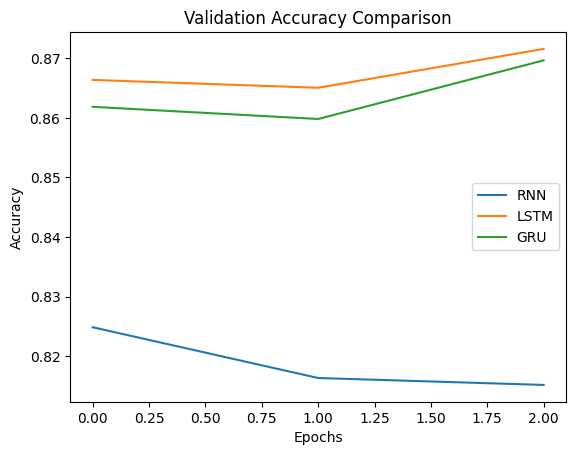

In [12]:
plt.figure()

plt.plot(history_rnn.history['val_accuracy'], label='RNN')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM')
plt.plot(history_gru.history['val_accuracy'], label='GRU')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()